# data cleaning

In [474]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import StandardScaler


# import 'Pandas' 
import pandas as pd 

# import 'Numpy' 
import numpy as np

# import subpackage of Matplotlib
import matplotlib.pyplot as plt

# import 'Seaborn' 
import seaborn as sns

# to suppress warnings 
from warnings import filterwarnings
filterwarnings('ignore')

# display all columns of the dataframe
pd.options.display.max_columns = None

# display all rows of the dataframe
pd.options.display.max_rows = None
 
# to display the float values upto 6 decimal places     
pd.options.display.float_format = '{:.6f}'.format

# import train-test split 
from sklearn.model_selection import train_test_split

# # import various functions from statsmodels
# import statsmodels
import statsmodels.api as sm
# import statsmodels.stats.api as sms
# from statsmodels.graphics.gofplots import qqplot

# # import 'stats'
# from scipy import stats

# # 'metrics' from sklearn is used for evaluating the model performance
# from sklearn.metrics import mean_squared_error

# # import functions to perform feature selection
# from mlxtend.feature_selection import SequentialFeatureSelector as sfs
# #from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFE

# import function to perform linear regression
from sklearn.linear_model import LinearRegression

# import functions to perform cross validation
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold



from sklearn.neighbors import KNeighborsRegressor


# from thefuzz import process
# from difflib import get_close_matches



In [476]:
"""
# Geocoding using GoogleV3
# this has been done and saved for future steps
# so that we don't exhaust the API calls limit
# this code is just for reference

# the code takes location names and generates location coordinates



train = pd.read_csv('train_(2)_(1)_(1)_(1).csv')
test = pd.read_csv('test_(2)_(1)_(1)_(1).csv')
avgRent = pd.read_csv('avg_rent_(1)_(1)_(1)_(1).csv')
disCityCenter = pd.read_csv('dist_from_city_centre_(1)_(1)_(1)_(1).csv')
sampleSubmission = pd.read_csv('sample_submission_(3)_(1)_(1)_(1).csv')

geolocator = GoogleV3(api_key="private key taken from gcp")


def geocodeFn(name):
    try:
        location = geolocator.geocode("bangalore " + name)
        return f'{location.latitude}, {location.longitude}'
    except:
        print("Error in geocoding for location:", name)
        return (np.nan, np.nan)


test['coordinates'] = test['location'].apply(lambda x: geocodeFn(x))
test[['latitude', 'longitude']] = test.coordinates.str.split(", ",expand=True)
test.to_csv("test.csv")

train.dropna(subset=['location'],inplace=True)
train['coordinates'] = train['location'].apply(lambda x: geocodeFn(x))
train[['latitude', 'longitude']] = train.coordinates.str.split(", ",expand=True)
train.to_csv("train.csv")

avgRent['coordinates'] = avgRent['location'].apply(lambda x: geocodeFn(x))
avgRent[['latitude', 'longitude']] = avgRent.coordinates.str.split(", ",expand=True)
avgRent.to_csv("avgRent.csv")

disCityCenter['coordinates'] = disCityCenter['location'].apply(lambda x: geocodeFn(x))
disCityCenter[['latitude', 'longitude']] = disCityCenter.coordinates.str.split(", ",expand=True)
disCityCenter.to_csv("disCityCenter.csv")


"""


'\n# Geocoding using GoogleV3\n# this has been done and saved for future steps\n# so that we don\'t exhaust the API calls limit\n# this code is just for reference\n\n# the code takes location names and generates location coordinates\n\n\n\ntrain = pd.read_csv(\'train_(2)_(1)_(1)_(1).csv\')\ntest = pd.read_csv(\'test_(2)_(1)_(1)_(1).csv\')\navgRent = pd.read_csv(\'avg_rent_(1)_(1)_(1)_(1).csv\')\ndisCityCenter = pd.read_csv(\'dist_from_city_centre_(1)_(1)_(1)_(1).csv\')\nsampleSubmission = pd.read_csv(\'sample_submission_(3)_(1)_(1)_(1).csv\')\n\ngeolocator = GoogleV3(api_key="private key taken from gcp")\n\n\ndef geocodeFn(name):\n    try:\n        location = geolocator.geocode("bangalore " + name)\n        return f\'{location.latitude}, {location.longitude}\'\n    except:\n        print("Error in geocoding for location:", name)\n        return (np.nan, np.nan)\n\n\ntest[\'coordinates\'] = test[\'location\'].apply(lambda x: geocodeFn(x))\ntest[[\'latitude\', \'longitude\']] = test.coor

In [477]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
avgRent = pd.read_csv('avgRent.csv')
disCityCenter = pd.read_csv('disCityCenter.csv')

In [478]:
print(test.info())
# test.dropna(subset=['size', 'location', 'bath', 'balcony'], inplace=True)
# test['size'].fillna(test['size'].mode(), inplace=True)

test['size'].fillna('2 BHK', inplace=True)
test['bath'].fillna(test['bath'].median(), inplace=True)
test['balcony'].fillna(test['balcony'].median(), inplace=True)
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2664 entries, 0 to 2663
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    2664 non-null   int64  
 1   ID            2664 non-null   int64  
 2   area_type     2664 non-null   object 
 3   availability  2664 non-null   object 
 4   location      2664 non-null   object 
 5   size          2662 non-null   object 
 6   society       1590 non-null   object 
 7   total_sqft    2664 non-null   object 
 8   bath          2656 non-null   float64
 9   balcony       2559 non-null   float64
 10  coordinates   2664 non-null   object 
 11  latitude      2664 non-null   float64
 12  longitude     2664 non-null   float64
dtypes: float64(4), int64(2), object(7)
memory usage: 270.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2664 entries, 0 to 2663
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        ----------

In [479]:



print(train.info())
train.dropna(subset=['size', 'location', 'bath', 'balcony'], inplace=True)
print(train.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10655 entries, 0 to 10654
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    10655 non-null  int64  
 1   ID            10655 non-null  int64  
 2   area_type     10655 non-null  object 
 3   availability  10655 non-null  object 
 4   location      10655 non-null  object 
 5   size          10641 non-null  object 
 6   society       6227 non-null   object 
 7   total_sqft    10655 non-null  object 
 8   bath          10590 non-null  float64
 9   balcony       10151 non-null  float64
 10  price         10655 non-null  float64
 11  coordinates   10655 non-null  object 
 12  latitude      10655 non-null  float64
 13  longitude     10655 non-null  float64
dtypes: float64(5), int64(2), object(7)
memory usage: 1.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 10151 entries, 0 to 10654
Data columns (total 14 columns):
 #   Column        Non-Null Coun

### cleaning total_sqft and making it numeric 
as it is expected to be in sq feet

then scaling it

In [480]:
def is_number(x):
    try:
        float(x)
        return True
    except ValueError:
        return False

def return_sqft(x):
    if is_number(x):
        return float(x)
    
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    if x.endswith('Sq. Meter') or x.endswith('Sq. Meter'):
        x = float(x.split('Sq')[0])
        return x*10.7639
    if x.endswith('Acres'):
        x = float(x.split('Acr')[0])
        return x*43560
    if x.endswith('Sq. Yards'):
        x = float(x.split('Sq')[0])
        return x*10.7639
    if x.endswith('Grounds'):
        x = float(x.split('Gro')[0])
        return x*2400
    if x.endswith('Cents'):
        x = float(x.split('Cen')[0])
        return x*435.6
    if x.endswith('Perch'):
        x = float(x.split('Per')[0])
        return x*272.25
    if x.endswith('Guntha'):
        x = float(x.split('Gun')[0])
        return x*1089
    
    print("Couldn't parse the value: ", x)
    return x



train['total_sqft'] = train.total_sqft.apply(lambda x: return_sqft(x))
train[train.total_sqft.apply(lambda x: is_number(x) == False)]


# train['price_per_sqft'] = train.price / train.total_sqft
# train.total_sqft.describe()


test['total_sqft'] = test.total_sqft.apply(lambda x: return_sqft(x))
test[test.total_sqft.apply(lambda x: is_number(x) == False)]


,Unnamed: 0,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,coordinates,latitude,longitude


outlier treatment for total_sqft based on area_type


OUTLIERS HAVE NOT YET BEEN TREATED AND MUST BE TREATED FOR ALL CATEGORIES

In [481]:
# # FOR SOME REASON THE R^2 IS REDUCING
# # ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^ HENCE THE CODE IS COMMENTED OUT ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

# # TODO: outlier analysis to be done wrt area type 

# # plt.subplots = plt.subplots(figsize=(10,5))


# print(train.area_type.value_counts())
# plt.figure(figsize=(20,10))


# plt.subplot(2,4,1)
# plt.title('Price per sqft distribution for Super built-up  Area')
# sns.boxplot(train[train.area_type == 'Super built-up  Area'].price_per_sqft)
# plt.subplot(2,4,5)
# plt.title('Price per sqft distribution for Super built-up  Area')
# sns.histplot(train[train.area_type == 'Super built-up  Area'].price_per_sqft)



# plt.subplot(2,4,2)
# plt.title('Price per sqft distribution for Built-up  Area')
# sns.boxplot(train[train.area_type == 'Built-up  Area'].price_per_sqft)
# plt.subplot(2,4,6)
# plt.title('Price per sqft distribution for Built-up  Area')
# sns.histplot(train[train.area_type == 'Built-up  Area'].price_per_sqft)



# plt.subplot(2,4,3)
# plt.title('Price per sqft distribution for Plot  Area')
# sns.boxplot(train[train.area_type == 'Plot  Area'].price_per_sqft)
# plt.subplot(2,4,7)
# plt.title('Price per sqft distribution for Plot  Area')
# sns.histplot(train[train.area_type == 'Plot  Area'].price_per_sqft)



# plt.subplot(2,4,4)
# plt.title('Price per sqft distribution for Carpet  Area')
# sns.boxplot(train[train.area_type == 'Carpet  Area'].price_per_sqft)
# plt.subplot(2,4,8)
# plt.title('Price per sqft distribution for Carpet  Area')
# sns.histplot(train[train.area_type == 'Carpet  Area'].price_per_sqft)



# plt.tight_layout()
# plt.show()

train['price_per_sqft'] = train.price / train.total_sqft
for i in train.area_type.unique():
    col = train[train.area_type == i].price_per_sqft
    iqr = (col.quantile(0.75) - col.quantile(0.25)) * (3/2)
    train.drop(train[(train.area_type == i) & (train.price_per_sqft > iqr)].index, inplace=True)



# for i in test.area_type.unique():
#     col = test[test.area_type == i].price_per_sqft
#     iqr = (col.quantile(0.75) - col.quantile(0.25)) * (3/2)
#     test.drop(test[(test.area_type == i) & (test.price_per_sqft > iqr)].index, inplace=True)

In [482]:
# print(train.price_per_sqft.describe())
# print(train[train.price_per_sqft > .6])
# train.drop(train[train.price_per_sqft > 0.6].index, inplace=True, axis=0)


In [483]:
# scaling data => total sq feet

# note that we must do outlier treatment before scaling
# min max scaling for total_sqft

# train.total_sqft = train.total_sqft.apply(lambda x: (x - train.total_sqft.min())/(train.total_sqft.max() - train.total_sqft.min()))

# all cols are being scaled later

successfully cleaned all non numeric data from total_sqft col

## handling size
- currently 1rk = 0
- 1bhk/1bedroom = 1
- 2bhk/2bedroom = 2 
and soo on

In [484]:
# print(train['size'].value_counts(dropna=False))
# train[train['size'].apply(lambda x: is_number(x) == False)]

def returnSize(x):
    try:
        if x == '1 RK':
            return 0
        else:
            return int(x.split(' ')[0])
    except:
        print("Couldn't parse size: ", x)


train['size'] = train['size'].apply(lambda x: returnSize(x))
test['size'] = test['size'].apply(lambda x: returnSize(x))

# train.info()



## avilibility


In [485]:
from datetime import datetime

# train.availability.value_counts()

def noOfDays(x):
    if x == 'Ready To Move' or x == 'Immediate Possession':
        return 0
    tokens = x.split('-')
    if len(tokens) == 2:
        now = datetime.now()

        date = datetime.strptime(f'{x}-{now.year}', '%d-%b-%Y')

        if (date - now).days < 0:
            date = datetime.strptime(f'{x}-{now.year + 1}', '%d-%b-%Y')
            
        return (date - now).days
    else:
        print("Couldn't parse availability: ", x)
        return -1


train.availability = train.availability.apply(lambda x: noOfDays(x))
test.availability = test.availability.apply(lambda x: noOfDays(x))

# train.info()


## encoding area type

n-1 dummy encoding performed 

with value counts

- area_type
- Super built-up  Area    6745
- Built-up  Area          1845
- Plot  Area              1496
- Carpet  Area              65

model performance to be tested including only Super built-up  Area 

In [486]:
areaTypes = train.area_type.unique()

temp = True
for i in areaTypes:
    if temp:
        temp = False
        continue
    train["area_type_" + i.split("  ")[0].replace(" ", "_").replace("-", "_")] = train.area_type.apply(lambda x: 1 if x==i else 0)

train.drop('area_type', axis=1, inplace=True)


temp = True
for i in areaTypes:
    if temp:
        temp = False
        continue
    test["area_type_" + i.split("  ")[0].replace(" ", "_").replace("-", "_")] = test.area_type.apply(lambda x: 1 if x==i else 0)

test.drop('area_type', axis=1, inplace=True)

# using average rent and distance from city center

In [487]:

# # Function to find the best match and its score using thefuzz.process.extractOne
# def find_closest_match(target, choices):
#     # process.extractOne returns a tuple: (closest_match, score, index)
#     match, score, _ = process.extractOne(target, choices)
#     return match, score

# # Apply the function across rows
# # The result will be a new DataFrame or Series containing the match and score
# train[['avgRentPlace', 'avgRentScore']] = train['location'].apply(
#     lambda x: pd.Series(find_closest_match(x, avgRent['location']))
# )


# train['average_rent'] = train.apply(
#     lambda row: avgRent.loc[avgRent['location'] == row['avgRentPlace'], 'avg_2bhk_rent'].values[0],
#     axis=1
# )

# # train.drop(['avgRentPlace', 'avgRentScore'], axis=1, inplace=True)


# train[['distanceField', 'distanceScore']] = train['location'].apply(
#     lambda x: pd.Series(find_closest_match(x, disCityCenter['location']))
# )

# train["distance_from_city_center"] = train.apply(
#     lambda row: disCityCenter.loc[
#         disCityCenter["location"] == row["distanceField"], "dist_from_city"
#     ].values[0],
#     axis=1,
# )

# # train.drop(['distanceField', 'distanceScore'], axis=1, inplace=True)


In [488]:
train.head()

,Unnamed: 0,ID,availability,location,size,society,total_sqft,bath,balcony,price,coordinates,latitude,longitude,price_per_sqft,area_type_Super_built_up,area_type_Built_up,area_type_Carpet
1,1,1,0,Chikka Tirupathi,4,Theanmp,2600.000000,5.000000,3.000000,120.000000,"12.8967455, 77.86674160000001",12.896745,77.866742,0.046154,0,0,0
5,5,5,0,Whitefield,2,DuenaTa,1170.000000,2.000000,1.000000,38.000000,"12.9698196, 77.7499721",12.969820,77.749972,0.032479,1,0,0
11,11,11,0,Whitefield,4,Prrry M,2785.000000,5.000000,3.000000,295.000000,"12.9698196, 77.7499721",12.969820,77.749972,0.105925,0,0,0
13,13,13,0,Gottigere,2,NaN,1100.000000,2.000000,2.000000,40.000000,"12.856443, 77.58884479999999",12.856443,77.588845,0.036364,0,1,0
14,14,14,0,Sarjapur,3,Skityer,2250.000000,3.000000,2.000000,148.000000,"12.8575579, 77.7864057",12.857558,77.786406,0.065778,0,0,0


<Axes: >

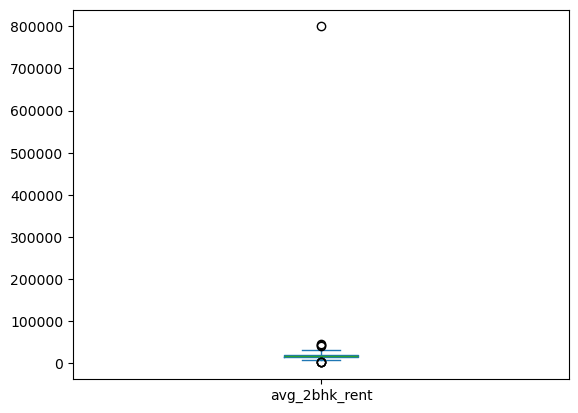

In [489]:
# 

avgRent.sort_values('avg_2bhk_rent')['avg_2bhk_rent'].plot(kind='box')


In [490]:
q1 = avgRent.avg_2bhk_rent.quantile(0.25)
q3 = avgRent.avg_2bhk_rent.quantile(0.75)

iqr = q3 - q1
lim = (3 / 2) * iqr

avgRent = avgRent.drop(
    avgRent[
        (avgRent.avg_2bhk_rent > q3 + lim) | (avgRent.avg_2bhk_rent < q1 - lim)
    ].index
)

In [491]:
# 2. Prepare the Coordinates
# KNN expects an array of [[lat1, lon1], [lat2, lon2]...]
coords_rental = avgRent[['latitude', 'longitude']].values
prices_rental = avgRent['avg_2bhk_rent'].values

In [492]:
knn = KNeighborsRegressor(n_neighbors=1, weights='distance', metric='euclidean')
knn.fit(coords_rental, prices_rental)

KNeighborsRegressor(metric='euclidean', n_neighbors=1, weights='distance')

In [493]:
train['estimated_rental_price'] = knn.predict(train[['latitude', 'longitude']].values)

test['estimated_rental_price'] = knn.predict(test[['latitude', 'longitude']].values)


In [494]:
# q1 = disCityCenter.dist_from_city.quantile(0.25)
# q3 = disCityCenter.dist_from_city.quantile(0.75)

# iqr = q3 - q1
# lim = (3 / 2) * iqr

# disCityCenter = disCityCenter.drop(
#     disCityCenter[
#         (disCityCenter.dist_from_city > q3 + lim)
#         | (disCityCenter.dist_from_city < q1 - lim)
#     ].index
# )

In [495]:
# # 2. Prepare the Coordinates
# # KNN expects an array of [[lat1, lon1], [lat2, lon2]...]
# coords_disCity = disCityCenter[['latitude', 'longitude']].values
# prices_disCity = disCityCenter['dist_from_city'].values

# knn = KNeighborsRegressor(n_neighbors=1, weights='distance', metric='euclidean')
# knn.fit(coords_disCity, prices_disCity)

# main_coords = train[['latitude', 'longitude']].values
# train['estimated_distance_city_center'] = knn.predict(main_coords)


In [496]:
# 12.9628669 77.57750899999999

def myFn(coo):
    a = coo.split(', ')
    lat = a[0]
    long = a[1]
    a = (float(lat) - 12.9628669) ** 2
    b = (float(long) - 77.57750899999999) ** 2
    return (a + b) ** 0.5
# 

train['estimated_distance_city_center'] = train.coordinates.apply(myFn)

test['estimated_distance_city_center'] = train.coordinates.apply(myFn)

In [497]:

# I dont want to scale the target variable
y = train['price']

# standard scaling

In [498]:
scaler = StandardScaler()

numeric_cols = train.select_dtypes(include=[np.number]).columns
train[numeric_cols] = scaler.fit_transform(train[numeric_cols])

In [499]:
numeric_cols = test.select_dtypes(include=[np.number]).columns
test[numeric_cols] = scaler.fit_transform(test[numeric_cols])

In [500]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2664 entries, 0 to 2663
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      2664 non-null   float64
 1   ID                              2664 non-null   float64
 2   availability                    2664 non-null   float64
 3   location                        2664 non-null   object 
 4   size                            2664 non-null   float64
 5   society                         1590 non-null   object 
 6   total_sqft                      2664 non-null   float64
 7   bath                            2664 non-null   float64
 8   balcony                         2664 non-null   float64
 9   coordinates                     2664 non-null   object 
 10  latitude                        2664 non-null   float64
 11  longitude                       2664 non-null   float64
 12  area_type_Super_built_up        26

In [501]:
test.head()

,Unnamed: 0,ID,availability,location,size,society,total_sqft,bath,balcony,coordinates,latitude,longitude,area_type_Super_built_up,area_type_Built_up,area_type_Carpet,estimated_rental_price,estimated_distance_city_center
0,-1.731401,-1.731401,-0.424467,Chamrajpet,-0.661886,NaN,-0.196237,-1.311147,-0.774311,"12.9569869, 77.5621397",-0.013095,-0.933204,0.704123,-0.475347,-0.082479,-0.128447,NaN
1,-1.730100,-1.730100,-0.424467,7th Phase JP Nagar,0.153308,SrncyRe,-0.057916,-0.539236,-0.774311,"12.8978624, 77.58450839999999",-0.724154,-0.632557,0.704123,-0.475347,-0.082479,1.088381,2.631080
2,-1.728800,-1.728800,-0.424467,Whitefield,0.153308,AjhalNa,0.010284,0.232674,0.493522,"12.9698196, 77.7499721",0.141237,1.591363,0.704123,-0.475347,-0.082479,-0.321842,NaN
3,-1.727500,-1.727500,-0.424467,Jalahalli,-0.661886,NaN,-0.128998,-0.539236,-2.042145,"13.0454314, 77.5478699",1.050579,-1.124998,-1.420207,2.103726,-0.082479,-1.183032,NaN
4,-1.726199,-1.726199,-0.424467,TC Palaya,-1.477080,NaN,-0.061759,-1.311147,-2.042145,"13.0190631, 77.7037131",0.733462,0.969618,-1.420207,-0.475347,-0.082479,-0.976658,NaN


In [502]:
train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2122 entries, 1 to 10650
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      2122 non-null   float64
 1   ID                              2122 non-null   float64
 2   availability                    2122 non-null   float64
 3   location                        2122 non-null   object 
 4   size                            2122 non-null   float64
 5   society                         831 non-null    object 
 6   total_sqft                      2122 non-null   float64
 7   bath                            2122 non-null   float64
 8   balcony                         2122 non-null   float64
 9   price                           2122 non-null   float64
 10  coordinates                     2122 non-null   object 
 11  latitude                        2122 non-null   float64
 12  longitude                       2122 n

In [503]:
test.head()

,Unnamed: 0,ID,availability,location,size,society,total_sqft,bath,balcony,coordinates,latitude,longitude,area_type_Super_built_up,area_type_Built_up,area_type_Carpet,estimated_rental_price,estimated_distance_city_center
0,-1.731401,-1.731401,-0.424467,Chamrajpet,-0.661886,NaN,-0.196237,-1.311147,-0.774311,"12.9569869, 77.5621397",-0.013095,-0.933204,0.704123,-0.475347,-0.082479,-0.128447,NaN
1,-1.730100,-1.730100,-0.424467,7th Phase JP Nagar,0.153308,SrncyRe,-0.057916,-0.539236,-0.774311,"12.8978624, 77.58450839999999",-0.724154,-0.632557,0.704123,-0.475347,-0.082479,1.088381,2.631080
2,-1.728800,-1.728800,-0.424467,Whitefield,0.153308,AjhalNa,0.010284,0.232674,0.493522,"12.9698196, 77.7499721",0.141237,1.591363,0.704123,-0.475347,-0.082479,-0.321842,NaN
3,-1.727500,-1.727500,-0.424467,Jalahalli,-0.661886,NaN,-0.128998,-0.539236,-2.042145,"13.0454314, 77.5478699",1.050579,-1.124998,-1.420207,2.103726,-0.082479,-1.183032,NaN
4,-1.726199,-1.726199,-0.424467,TC Palaya,-1.477080,NaN,-0.061759,-1.311147,-2.042145,"13.0190631, 77.7037131",0.733462,0.969618,-1.420207,-0.475347,-0.082479,-0.976658,NaN


In [504]:
train.drop(['price_per_sqft'], axis=1, inplace=True)

x = train.drop('price', axis=1)
# y = train['price']

x = x.select_dtypes(include= 'number')
x = sm.add_constant(x)

X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=1, test_size = 0.2)


In [505]:
X_train.head()

,const,Unnamed: 0,ID,availability,size,total_sqft,bath,balcony,latitude,longitude,area_type_Super_built_up,area_type_Built_up,area_type_Carpet,estimated_rental_price,estimated_distance_city_center
716,1.000000,-1.517631,-1.517631,-0.464422,-0.602064,-0.054573,-0.472621,0.712635,-0.435565,-1.578267,1.291968,-0.442907,-0.072186,-0.732952,-0.270999
7910,1.000000,0.824880,0.824880,-0.464422,-0.602064,-0.059114,-0.472621,-0.451500,0.386074,0.282218,-0.774013,-0.442907,13.853126,0.221727,-0.591553
1210,1.000000,-1.356775,-1.356775,-0.464422,1.404605,-0.043222,1.550720,-0.451500,-0.635227,-0.153180,-0.774013,-0.442907,-0.072186,-1.581556,-0.518565
3825,1.000000,-0.505278,-0.505278,0.797844,0.066826,-0.052019,0.201826,0.712635,-0.201689,-0.278257,1.291968,-0.442907,-0.072186,-0.061070,-1.097845
9340,1.000000,1.290517,1.290517,-0.464422,0.066826,-0.052019,-0.472621,0.712635,0.367911,0.446283,-0.774013,2.257809,-0.072186,0.616965,-0.395723


In [506]:
# 0.389
# 0.392


myModel = sm.OLS(y_train, X_train).fit()
myModel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                     84.64
Date:                Sat, 17 Jan 2026   Prob (F-statistic):          3.76e-173
Time:                        20:31:06   Log-Likelihood:                -9530.1
No. Observations:                1697   AIC:                         1.909e+04
Df Residuals:                    1683   BIC:                         1.916e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             80.6143      1.621     49.720      0.000      77.434      83.794
Unnamed: 0                         0.3624      0.805      0.450      0.652      -1.216       1.940
ID                                 0.3624      0.805      0.450      0.652      -1.216       1.940
availability                      -2.9991      1.688     -1.776      0.076      -6.310       0.312
size                              -9.0084      3.725     -2.418      0.016     -16.315      -1.702
total_sqft                         1.0601      1.595      0.665      0.506      -2.068       4.188
bath                              30.2282      3.792      7.972      0.000      22.791      37.665
balcony                           13.5400      1.753      7.723      0.000      10.101      16.979
latitude                           3.0010      1.843      1.628      0.104      -0.614       6.616
longitude                          3.2283      1.699      1.900      0.058      -0.105       6.562
area_type_Super_built_up         -36.5025      2.030    -17.985      0.000     -40.483     -32.522
area_type_Built_up               -25.2789      1.864    -13.559      0.000     -28.935     -21.622
area_type_Carpet                  -6.0294      1.621     -3.719      0.000      -9.210      -2.849
estimated_rental_price             3.4222      1.661      2.061      0.039       0.165       6.679
estimated_distance_city_center     3.7206      1.603      2.321      0.020       0.577       6.864
==============================================================================
Omnibus:                     1866.675   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           253593.261
Skew:                           5.239   Prob(JB):                         0.00
Kurtosis:                      61.963   Cond. No.                     1.49e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.83e-29. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [507]:
test = test.select_dtypes(include= 'number')
test = sm.add_constant(test)

In [508]:
with open('submit.csv', 'w') as f:
    f.write('ID,price\n')
    predictions = myModel.predict(test)
    for idx, pred in enumerate(predictions):
        f.write(f'{idx},{pred}\n')

In [509]:
for i in (myModel.predict(test)):
    print(type(i))
    print(i)

<class 'float'>
nan
<class 'float'>
48.516576036175046
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
175.29427659940848
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
53.417924299495986
<class 'float'>
nan
<class 'float'>
27.285373547912542
<class 'float'>
78.65503930450868
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
49.540649344540135
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
42.54134054489928
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
110.2105019548502
<class 'float'>
nan
<class 'float'>
40.647117134869994
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
nan
<class 'float'>
98.45284120809494
<class 'float'